**TKO-7094 Introduction to Deep Learning course project**

Iida Pyykkönen
(2001292)


In [ ]:
#!pip install matplotlib pandas tensorflow_model_optimization seaborn

In [ ]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np
import keras
import pandas as pd
import seaborn as sns
from tensorflow.keras.preprocessing import image_dataset_from_directory
import pickle

In [ ]:
# Hardware usage limitations
gpus = tf.config.experimental.list_physical_devices('GPU')
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

print("Num GPUs Available: ", len(gpus))

Num GPUs Available:  1


# Functions

In [ ]:
def create_models(input_shape, final_dense_layer_size):
    model_list, modification_list = [], []

    modification_list.append('Base model')

    model = keras.Sequential([
              layers.Input(shape=input_shape),
              layers.Conv2D(32, (3, 3), activation='relu'),
              layers.MaxPooling2D((2, 2)),
              layers.Conv2D(64, (3, 3), activation='relu'),
              layers.MaxPooling2D((2, 2)),
              layers.Conv2D(64, (3, 3), activation='relu'),
              layers.Flatten(),
              layers.Dense(128, activation='relu'),
              layers.Dense(64, activation='relu'),
              layers.Dense(final_dense_layer_size, activation='softmax'),
          ])

    model_list.append(model)

    # Bigger dense layers
    modification_list.append('Bigger dense layers')

    model = keras.Sequential([
              layers.Input(shape=input_shape),
              layers.Conv2D(32, (3, 3), activation='relu'),
              layers.MaxPooling2D((2, 2)),
              layers.Conv2D(64, (3, 3), activation='relu'),
              layers.MaxPooling2D((2, 2)),
              layers.Conv2D(64, (3, 3), activation='relu'),
              layers.Flatten(),
              layers.Dense(1024, activation='relu'),
              layers.Dense(512, activation='relu'),
              layers.Dense(final_dense_layer_size, activation='softmax')
          ])

    model_list.append(model)

    # More dense layers
    modification_list.append('More dense layers')

    model = keras.Sequential([
              layers.Input(shape=input_shape),
              layers.Conv2D(32, (3, 3), activation='relu'),
              layers.MaxPooling2D((2, 2)),
              layers.Conv2D(64, (3, 3), activation='relu'),
              layers.MaxPooling2D((2, 2)),
              layers.Conv2D(64, (3, 3), activation='relu'),
              layers.Flatten(),
              layers.Dense(1024, activation='relu'),
              layers.Dense(512, activation='relu'),
              layers.Dense(256, activation='relu'),
              layers.Dense(128, activation='relu'),
              layers.Dense(64, activation='relu'),
              layers.Dense(final_dense_layer_size, activation='softmax'),
          ])

    model_list.append(model)

    # More dense layers with dropout
    modification_list.append('More dense layers with dropout')

    model = keras.Sequential([
              layers.Input(shape=input_shape),
              layers.Conv2D(32, (3, 3), activation='relu'),
              layers.MaxPooling2D((2, 2)),
              layers.Conv2D(64, (3, 3), activation='relu'),
              layers.MaxPooling2D((2, 2)),
              layers.Conv2D(64, (3, 3), activation='relu'),
              layers.Flatten(),
              layers.Dense(1024, activation='relu'),
              layers.Dropout(0.1),
              layers.Dense(512, activation='relu'),
              layers.Dropout(0.1),
              layers.Dense(256, activation='relu'),
              layers.Dropout(0.1),
              layers.Dense(128, activation='relu'),
              layers.Dropout(0.1),
              layers.Dense(64, activation='relu'),
              layers.Dropout(0.1),
              layers.Dense(final_dense_layer_size, activation='softmax'),
          ])

    model_list.append(model)

    # More convolution layers
    modification_list.append('More convolution layers')

    model = keras.Sequential([
              layers.Input(shape=input_shape),
              layers.Conv2D(32, (3, 3), activation='relu'),
              layers.MaxPooling2D((1, 1)),
              layers.Conv2D(64, (3, 3), activation='relu'),
              layers.MaxPooling2D((2, 2)),
              layers.Conv2D(64, (3, 3), activation='relu'),
              layers.MaxPooling2D((1, 1)),
              layers.Conv2D(64, (3, 3), activation='relu'),
              layers.MaxPooling2D((2, 2)),
              layers.Conv2D(64, (3, 3), activation='relu'),
              layers.Flatten(),
              layers.Dense(128, activation='relu'),
              layers.Dense(64, activation='relu'),
              layers.Dense(final_dense_layer_size, activation='softmax'),
          ])

    model_list.append(model)

    # More convolution and dense layers
    modification_list.append('More convolution and dense layers')

    model = keras.Sequential([
              layers.Input(shape=input_shape),
              layers.Conv2D(32, (3, 3), activation='relu'),
              layers.MaxPooling2D((1, 1)),
              layers.Conv2D(64, (3, 3), activation='relu'),
              layers.MaxPooling2D((2, 2)),
              layers.Conv2D(64, (3, 3), activation='relu'),
              layers.MaxPooling2D((1, 1)),
              layers.Conv2D(64, (3, 3), activation='relu'),
              layers.MaxPooling2D((2, 2)),
              layers.Conv2D(64, (3, 3), activation='relu'),
              layers.Flatten(),
              layers.Dense(512, activation='relu'),
              layers.Dense(256, activation='relu'),
              layers.Dense(128, activation='relu'),
              layers.Dense(64, activation='relu'),
              layers.Dense(final_dense_layer_size, activation='softmax'),
          ])

    model_list.append(model)

    # Linear activation function
    modification_list.append('Linear activation function')

    model = keras.Sequential([
              layers.Input(shape=input_shape),
              layers.Conv2D(32, (3, 3), activation='linear'),
              layers.MaxPooling2D((2, 2)),
              layers.Conv2D(64, (3, 3), activation='linear'),
              layers.MaxPooling2D((2, 2)),
              layers.Conv2D(64, (3, 3), activation='linear'),
              layers.Flatten(),
              layers.Dense(128, activation='linear'),
              layers.Dense(64, activation='linear'),
              layers.Dense(final_dense_layer_size, activation='softmax'),
          ])

    model_list.append(model)

    # Sigmoid activation function
    modification_list.append('Sigmoid activation function')

    model = keras.Sequential([
              layers.Input(shape=input_shape),
              layers.Conv2D(32, (3, 3), activation='sigmoid'),
              layers.MaxPooling2D((2, 2)),
              layers.Conv2D(64, (3, 3), activation='sigmoid'),
              layers.MaxPooling2D((2, 2)),
              layers.Conv2D(64, (3, 3), activation='sigmoid'),
              layers.Flatten(),
              layers.Dense(128, activation='sigmoid'),
              layers.Dense(64, activation='sigmoid'),
              layers.Dense(final_dense_layer_size, activation='softmax'),
          ])

    model_list.append(model)

    # Bigger net with linear activation
    modification_list.append('Bigger net with linear activation')

    model = keras.Sequential([
              layers.Input(shape=input_shape),
              layers.Conv2D(32, (3, 3), activation='linear'),
              layers.MaxPooling2D((1, 1)),
              layers.Conv2D(64, (3, 3), activation='linear'),
              layers.MaxPooling2D((1, 1)),
              layers.Conv2D(64, (3, 3), activation='linear'),
              layers.MaxPooling2D((1, 1)),
              layers.Conv2D(64, (3, 3), activation='linear'),
              layers.MaxPooling2D((1, 1)),
              layers.Conv2D(64, (3, 3), activation='linear'),
              layers.Flatten(),
              layers.Dense(256, activation='linear'),
              layers.Dense(128, activation='linear'),
              layers.Dense(64, activation='linear'),
              layers.Dense(final_dense_layer_size, activation='softmax'),
          ])

    model_list.append(model)

    # Bigger net with sigmoid activation
    modification_list.append('Bigger net with sigmoid activation')

    model = keras.Sequential([
              layers.Input(shape=input_shape),
              layers.Conv2D(32, (3, 3), activation='linear'),
              layers.MaxPooling2D((1, 1)),
              layers.Conv2D(64, (3, 3), activation='linear'),
              layers.MaxPooling2D((1, 1)),
              layers.Conv2D(64, (3, 3), activation='linear'),
              layers.MaxPooling2D((1, 1)),
              layers.Conv2D(64, (3, 3), activation='linear'),
              layers.MaxPooling2D((1, 1)),
              layers.Conv2D(64, (3, 3), activation='linear'),
              layers.Flatten(),
              layers.Dense(256, activation='linear'),
              layers.Dense(128, activation='linear'),
              layers.Dense(64, activation='linear'),
              layers.Dense(final_dense_layer_size, activation='softmax'),
          ])

    model_list.append(model)

    return model_list, modification_list

In [ ]:
def compile_and_fit(model_list, modification_list, train_images, train_labels, test_images, test_labels,
                    optimizer, epochs, learning_rate, batch_size, fit_verbose=0, eval_verbose=2):
    results = []

    for i, model in enumerate(model_list):
        modification = modification_list[i]

        opt = tf.keras.optimizers.get(optimizer)
        opt.learning_rate = learning_rate

        model.compile(optimizer=opt, loss=tf.keras.losses.SparseCategoricalCrossentropy(), metrics=['accuracy'])

        history = model.fit(train_images, train_labels, epochs=epochs, batch_size=batch_size,
                            validation_data=(test_images, test_labels), verbose=fit_verbose)

        train_accuracy = history.history['accuracy'][-1]
        train_loss = history.history['loss'][-1]

        test_loss, test_accuracy = model.evaluate(test_images, test_labels, verbose=eval_verbose)

        results.append({
            'Modification': modification,
            'Optimizer': optimizer,
            'Epochs': epochs,
            'Learning_rate': learning_rate,
            'Batch_size': batch_size,
            'Train_accuracy': train_accuracy,
            'Train_loss': train_loss,
            'Test_accuracy': test_accuracy,
            'Test_loss': test_loss
        })

    results_df = pd.DataFrame(results)

    return results_df

In [ ]:
def train_and_test(epochs, learning_rates, batch_sizes, optimizer, num_classes):
    results = pd.DataFrame()

    for epoch in epochs:
        for learning_rate in learning_rates:
            for batch_size in batch_sizes:
                # Create models, load data
                model_list, modification_list = create_models((32, 32, 3), num_classes)
                load_data(indices)

                # Train and test
                df = compile_and_fit(model_list=model_list, modification_list=modification_list,
                                   train_images=train_images, train_labels=train_labels,
                                   test_images=test_images, test_labels=test_labels,
                                   optimizer=optimizer, epochs=epoch,
                                   learning_rate=learning_rate, batch_size=batch_size)

                # Properly concatenate the results
                results = pd.concat([results, df], ignore_index=True)

                # Clear gpu memory to prevent OOM
                tf.keras.backend.clear_session()

    # save results to a file in case this crashes again
    with open(f'{optimizer}.pkl', 'wb') as f:
          pickle.dump(results, f)

    return results

In [ ]:
def visualize_results_heatmap(results_df):
    epochs = results_df['Epochs'].unique()
    learning_rates = results_df['Learning_rate'].unique()
    batch_sizes = results_df['Batch_size'].unique()
    optimizer = results_df['Optimizer'].unique()[0]

    num_rows = len(epochs)
    fig, axes = plt.subplots(num_rows, 2, figsize=(15, 4 * num_rows), sharey=True)

    # Ensure axes is a 2D array even if num_rows is 1
    if num_rows == 1:
        axes = np.array([axes])

    global_min = 1.0
    global_max = 0.0

    modifications = results_df['Modification'].unique()

    for i, epoch in enumerate(epochs):
        train_heatmap_data = []
        test_heatmap_data = []

        for modification in modifications:
            train_row_data = []
            test_row_data = []
            for lr in learning_rates:
                for batch_size in batch_sizes:
                    row = results_df[
                        (results_df['Epochs'] == epoch) &
                        (results_df['Optimizer'] == optimizer) &
                        (results_df['Learning_rate'] == lr) &
                        (results_df['Batch_size'] == batch_size) &
                        (results_df['Modification'] == modification)
                    ]

                    if not row.empty:
                        test_accuracy = row['Test_accuracy'].values[0]
                        train_accuracy = row['Train_accuracy'].values[0]
                        test_row_data.append(test_accuracy)
                        train_row_data.append(train_accuracy)
                    else:
                        # Append NaN if no data is found
                        test_row_data.append(np.nan)
                        train_row_data.append(np.nan)

            test_heatmap_data.append(test_row_data)
            train_heatmap_data.append(train_row_data)

        train_heatmap_data = np.array(train_heatmap_data)
        test_heatmap_data = np.array(test_heatmap_data)

        # Update min and max
        global_min = min(global_min, np.nanmin(train_heatmap_data), np.nanmin(test_heatmap_data))
        global_max = max(global_max, np.nanmax(train_heatmap_data), np.nanmax(test_heatmap_data))

        # Plot train accuracy heatmap
        sns.heatmap(train_heatmap_data, annot=True, fmt=".2f", ax=axes[i, 0], cmap="YlGn",
                    xticklabels=[f'LR: {lr}, BS: {bs}' for lr in learning_rates for bs in batch_sizes],
                    yticklabels=modifications, cbar=True, vmin=global_min, vmax=global_max)
        axes[i, 0].set_title(f'Train Accuracy - Epochs: {epoch}')
        axes[i, 0].set_xlabel('Learning Rate and Batch Size')
        axes[i, 0].set_ylabel('Modification')

        # Plot test accuracy heatmap
        sns.heatmap(test_heatmap_data, annot=True, fmt=".2f", ax=axes[i, 1], cmap="YlGn",
                    xticklabels=[f'LR: {lr}, BS: {bs}' for lr in learning_rates for bs in batch_sizes],
                    yticklabels=modifications if i == num_rows - 1 else "", cbar=True, vmin=global_min, vmax=global_max)
        axes[i, 1].set_title(f'Test Accuracy - Epochs: {epoch}')
        axes[i, 1].set_xlabel('Learning Rate and Batch Size')
        axes[i, 1].set_ylabel('')

    plt.tight_layout()
    plt.show()

In [ ]:
def load_data(indices):
    # Load and normalize data
    (train_images, train_labels), (test_images, test_labels) = datasets.cifar100.load_data()

    # Filter data
    train_images = train_images[np.isin(train_labels, indices).flatten()]
    train_labels = train_labels[np.isin(train_labels, indices).flatten()]

    test_images = test_images[np.isin(test_labels, indices).flatten()]
    test_labels = test_labels[np.isin(test_labels, indices).flatten()]

    # Remap labels to be 0-4
    label_map = {class_idx: idx for idx, class_idx in enumerate(indices)}
    train_labels = np.array([label_map[label[0]] for label in train_labels])
    test_labels = np.array([label_map[label[0]] for label in test_labels])

    train_images, test_images = train_images / 255.0, test_images / 255.0

    return train_images, train_labels, test_images, test_labels

# CIFAR100: Insect classes

In [ ]:
indices = [6, 7, 14, 18, 24]
class_dict = {0: 'bee', 1: 'beetle', 2: 'butterfly', 3: 'caterpillar', 4: 'cockroach'}
train_images, train_labels, test_images, test_labels = load_data(indices)

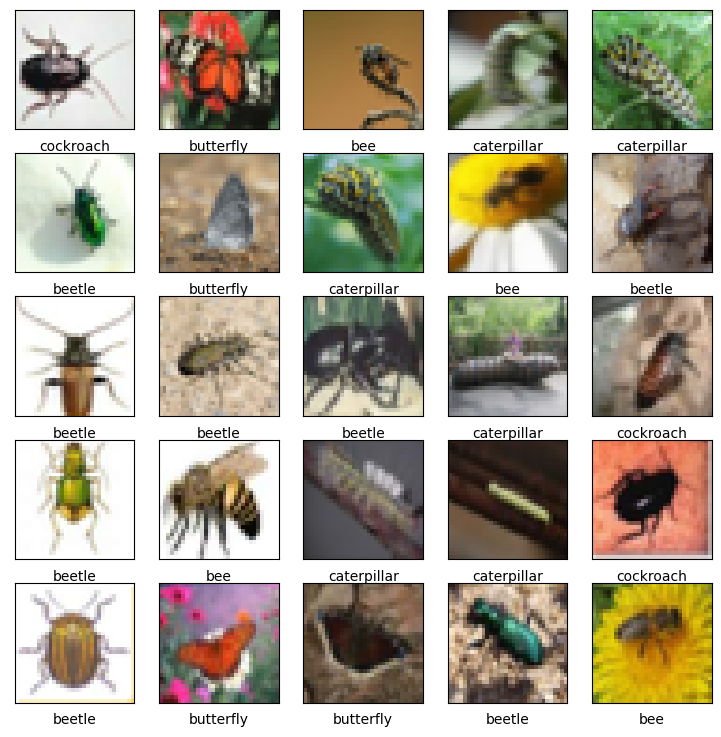

In [ ]:
# Data check
plt.figure(figsize=(9,9))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(train_images[i])
    label = train_labels[i]
    plt.xlabel(class_dict[label])
plt.show()

In [ ]:
model_list, modification_list = create_models((32, 32, 3))
print(modification_list)

Instructions for updating:
Lambda fuctions will be no more assumed to be used in the statement where they are used, or at least in the same block. https://github.com/tensorflow/tensorflow/issues/56089
['Base model', 'Bigger dense layers', 'More dense layers', 'More dense layers with dropout', 'More convolution layers', 'More convolution and dense layers', 'Linear activation function', 'Sigmoid activation function', 'Bigger net with linear activation', 'Bigger net with sigmoid activation']


## Adam

In [ ]:
# originally I had 0.01 as the final learning rate, but it produced only useless results
learning_rates = [0.0001, 0.001, 0.003]
batch_sizes = [16, 32, 64]
epochs =  [10, 20, 30]

In [ ]:
optimizer = 'adam'
results_adam = train_and_test(epochs, learning_rates, batch_sizes, optimizer)

16/16 - 0s - loss: 0.9924 - accuracy: 0.6080 - 152ms/epoch - 10ms/step
16/16 - 0s - loss: 0.9424 - accuracy: 0.6440 - 87ms/epoch - 5ms/step
16/16 - 0s - loss: 0.8993 - accuracy: 0.6720 - 94ms/epoch - 6ms/step
16/16 - 0s - loss: 1.0355 - accuracy: 0.5980 - 94ms/epoch - 6ms/step
16/16 - 0s - loss: 0.9775 - accuracy: 0.6460 - 270ms/epoch - 17ms/step
16/16 - 0s - loss: 1.0090 - accuracy: 0.6160 - 149ms/epoch - 9ms/step
16/16 - 0s - loss: 1.0752 - accuracy: 0.5720 - 144ms/epoch - 9ms/step
16/16 - 0s - loss: 1.4191 - accuracy: 0.3980 - 81ms/epoch - 5ms/step
16/16 - 0s - loss: 1.8462 - accuracy: 0.4300 - 304ms/epoch - 19ms/step
16/16 - 0s - loss: 1.6094 - accuracy: 0.2000 - 177ms/epoch - 11ms/step
16/16 - 0s - loss: 1.0946 - accuracy: 0.5680 - 101ms/epoch - 6ms/step
16/16 - 0s - loss: 0.9667 - accuracy: 0.6560 - 99ms/epoch - 6ms/step
16/16 - 0s - loss: 0.9991 - accuracy: 0.6100 - 97ms/epoch - 6ms/step
16/16 - 0s - loss: 0.9758 - accuracy: 0.6240 - 92ms/epoch - 6ms/step
16/16 - 0s - loss: 0.99

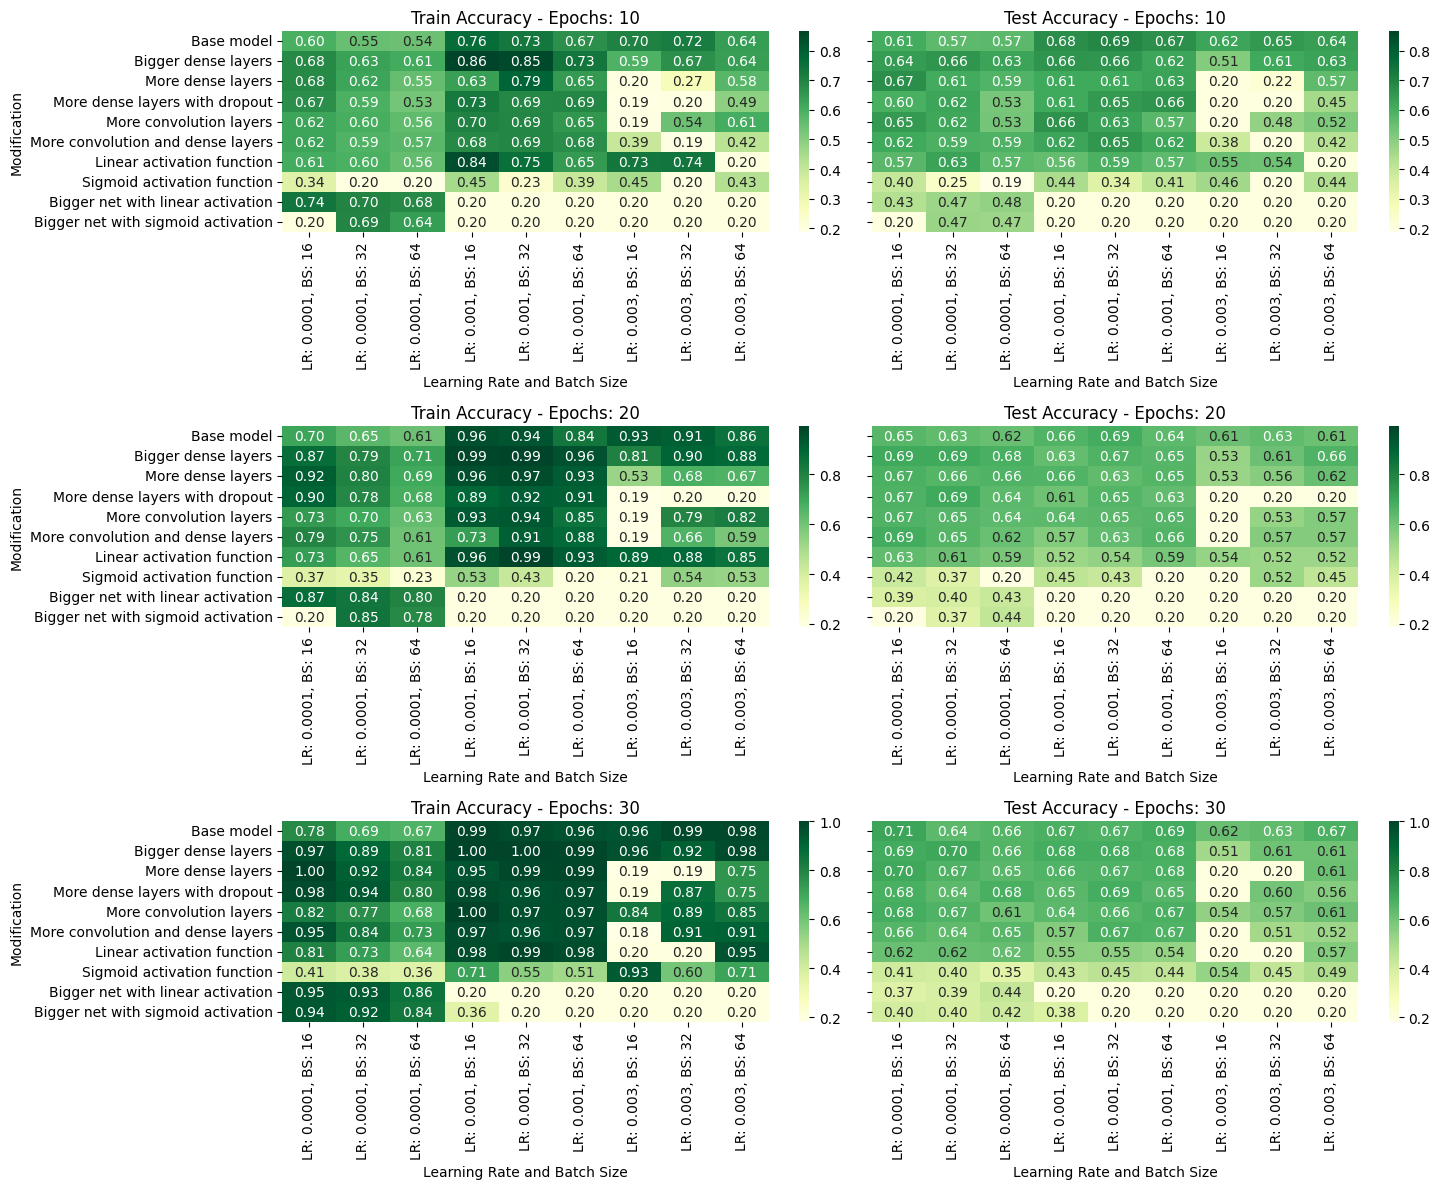

In [ ]:
visualize_results_heatmap(results_adam)

## RMSprop

In [ ]:
optimizer = 'rmsprop'
results_rmsprop = train_and_test(epochs, learning_rates, batch_sizes, optimizer)

16/16 - 0s - loss: 1.0996 - accuracy: 0.5700 - 94ms/epoch - 6ms/step
16/16 - 0s - loss: 1.0954 - accuracy: 0.5500 - 115ms/epoch - 7ms/step
16/16 - 0s - loss: 1.0076 - accuracy: 0.6200 - 99ms/epoch - 6ms/step
16/16 - 0s - loss: 1.0634 - accuracy: 0.5540 - 98ms/epoch - 6ms/step
16/16 - 0s - loss: 1.0785 - accuracy: 0.5700 - 161ms/epoch - 10ms/step
16/16 - 0s - loss: 1.0988 - accuracy: 0.5620 - 145ms/epoch - 9ms/step
16/16 - 0s - loss: 1.0752 - accuracy: 0.5960 - 102ms/epoch - 6ms/step
16/16 - 0s - loss: 1.6125 - accuracy: 0.2000 - 93ms/epoch - 6ms/step
16/16 - 0s - loss: 1.6840 - accuracy: 0.2000 - 185ms/epoch - 12ms/step
16/16 - 0s - loss: 1.6065 - accuracy: 0.2000 - 183ms/epoch - 11ms/step
16/16 - 0s - loss: 1.3095 - accuracy: 0.4500 - 89ms/epoch - 6ms/step
16/16 - 0s - loss: 1.1783 - accuracy: 0.4960 - 88ms/epoch - 6ms/step
16/16 - 0s - loss: 1.3349 - accuracy: 0.4580 - 100ms/epoch - 6ms/step
16/16 - 0s - loss: 1.1887 - accuracy: 0.5120 - 97ms/epoch - 6ms/step
16/16 - 0s - loss: 1.216

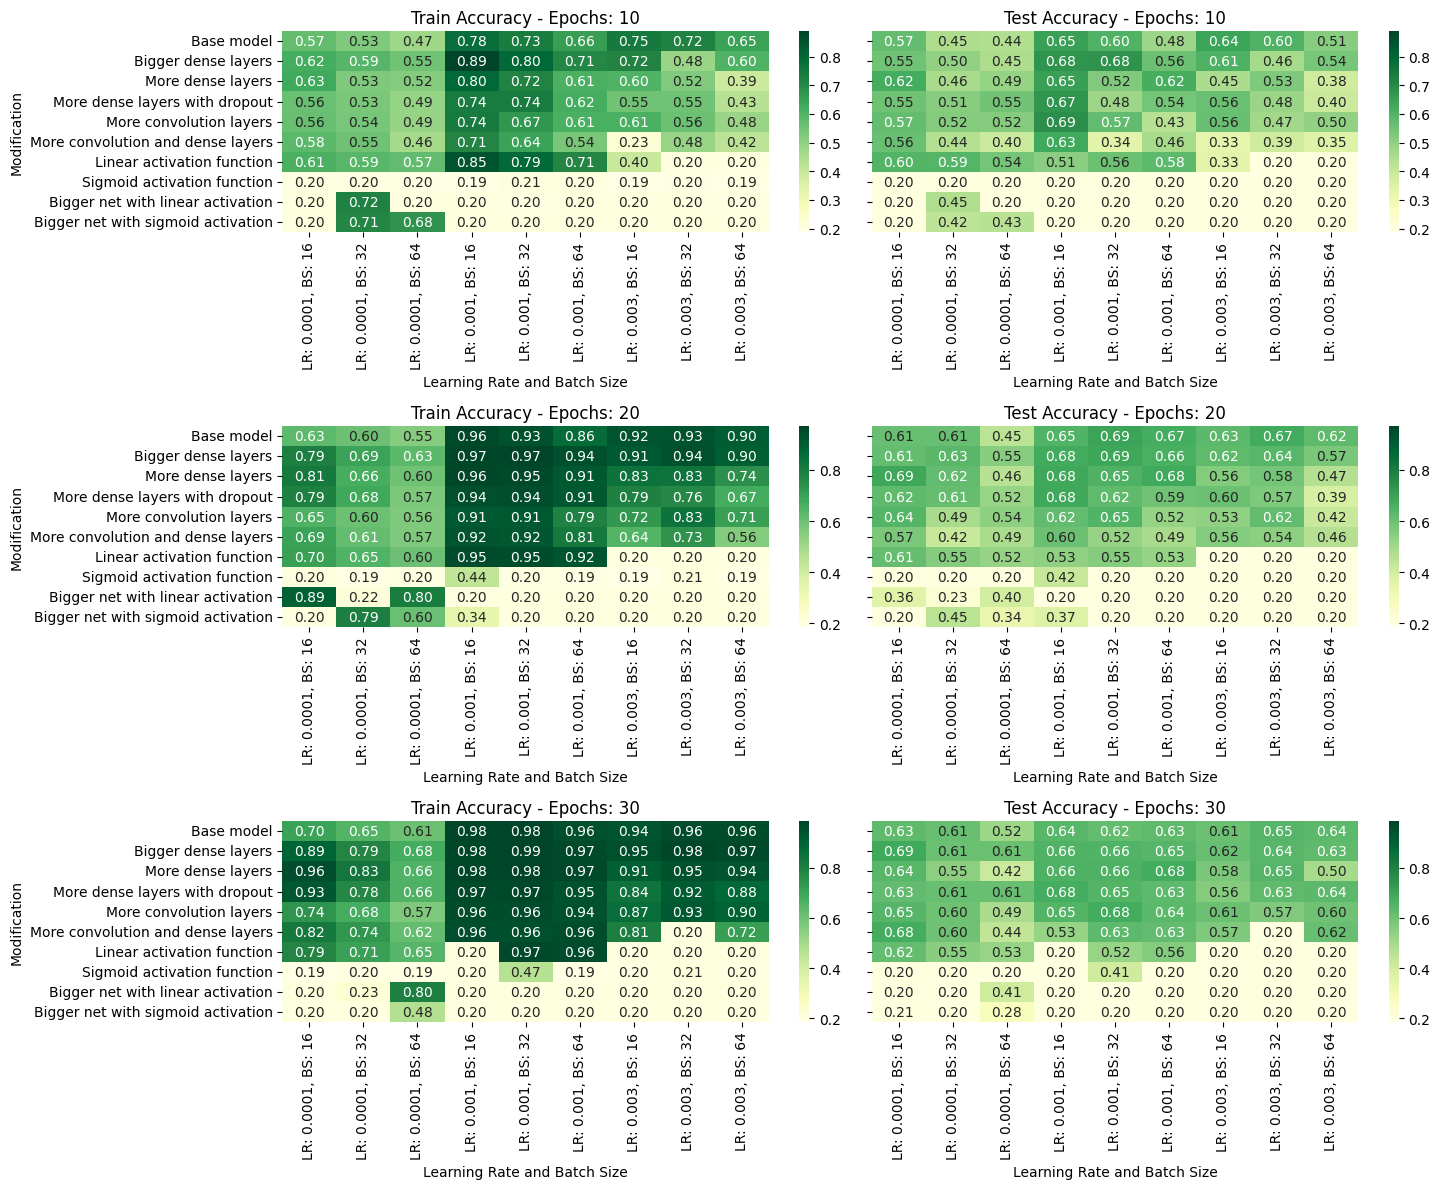

In [ ]:
visualize_results_heatmap(results_rmsprop)

## SGD

In [ ]:
# different learning rates since SGD default is higher
learning_rates = [0.001, 0.01, 0.1]
optimizer = 'sgd'
results_sgd =  train_and_test(epochs, learning_rates, batch_sizes, optimizer)

16/16 - 0s - loss: 1.5280 - accuracy: 0.3520 - 167ms/epoch - 10ms/step
16/16 - 0s - loss: 1.5504 - accuracy: 0.2840 - 105ms/epoch - 7ms/step
16/16 - 0s - loss: 1.5703 - accuracy: 0.2580 - 92ms/epoch - 6ms/step
16/16 - 0s - loss: 1.5991 - accuracy: 0.2240 - 98ms/epoch - 6ms/step
16/16 - 0s - loss: 1.5785 - accuracy: 0.2360 - 259ms/epoch - 16ms/step
16/16 - 0s - loss: 1.5963 - accuracy: 0.2960 - 136ms/epoch - 9ms/step
16/16 - 0s - loss: 1.2339 - accuracy: 0.5120 - 144ms/epoch - 9ms/step
16/16 - 0s - loss: 1.6095 - accuracy: 0.2000 - 83ms/epoch - 5ms/step
16/16 - 0s - loss: 1.2357 - accuracy: 0.5240 - 289ms/epoch - 18ms/step
16/16 - 0s - loss: 1.2107 - accuracy: 0.5340 - 168ms/epoch - 10ms/step
16/16 - 0s - loss: 1.5823 - accuracy: 0.2760 - 83ms/epoch - 5ms/step
16/16 - 0s - loss: 1.5714 - accuracy: 0.2840 - 93ms/epoch - 6ms/step
16/16 - 0s - loss: 1.6060 - accuracy: 0.2420 - 93ms/epoch - 6ms/step
16/16 - 0s - loss: 1.6049 - accuracy: 0.2640 - 104ms/epoch - 6ms/step
16/16 - 0s - loss: 1.6

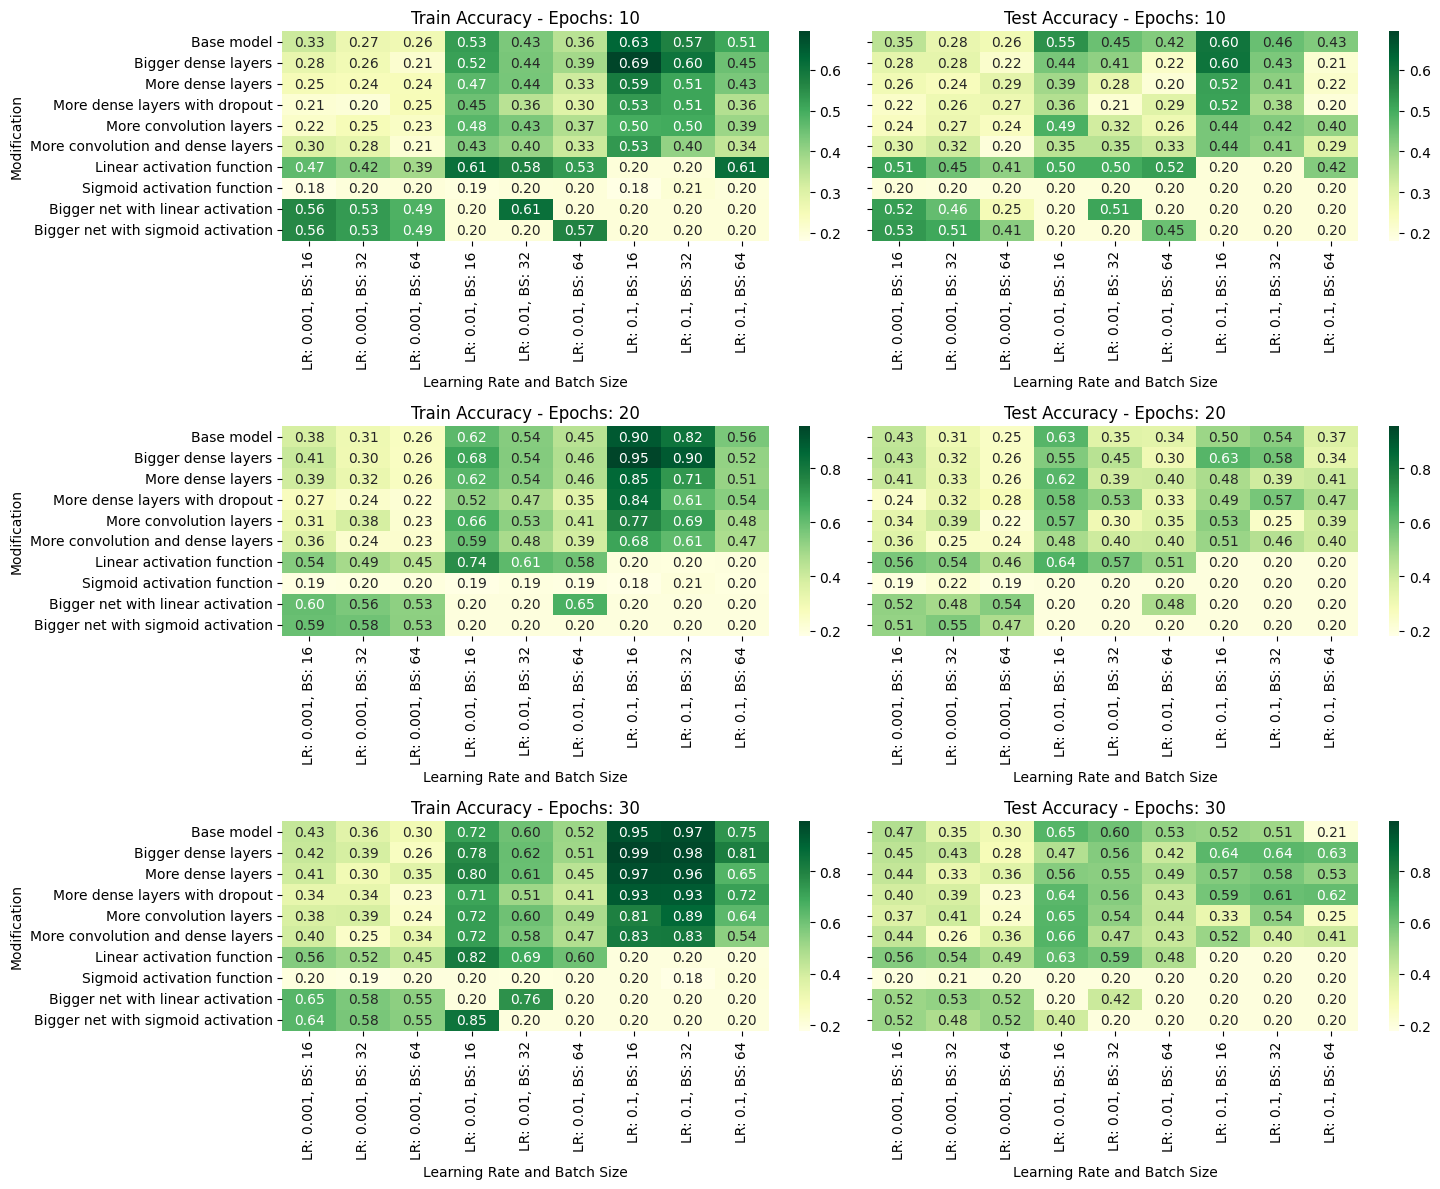

In [ ]:
visualize_results_heatmap(results_sgd)

# CIFAR100: Large Animals

In [ ]:
indices = [3, 15, 19, 31, 38, 42, 43, 88, 97]
train_images, train_labels, test_images, test_labels = load_data(indices)
class_dict = {0: 'bear', 1: 'camel', 2: 'cattle', 3: 'elephant', 4: 'kangaroo',
              5: 'leopard', 6: 'lion', 7: 'tiger', 8: 'wolf'}
num_classes = len(indices)

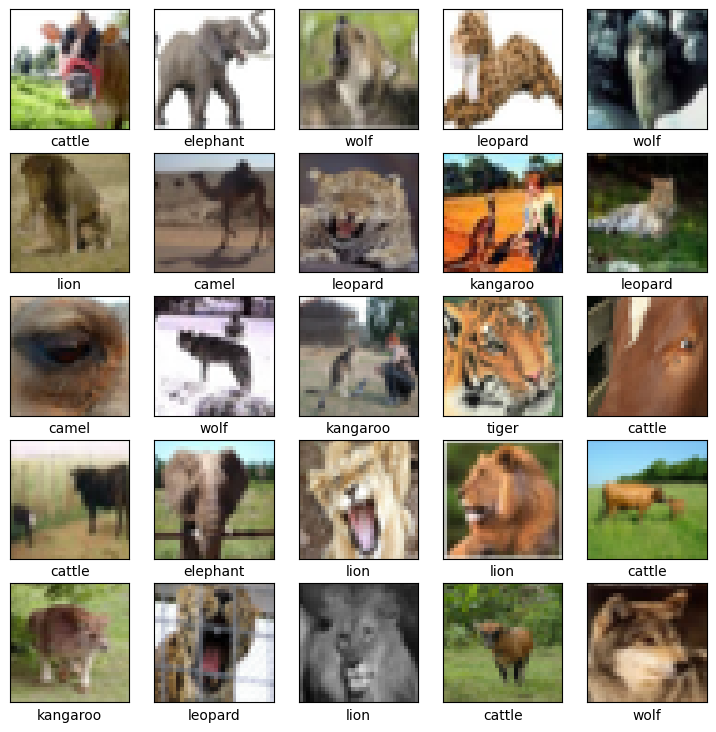

In [ ]:
# Data check
plt.figure(figsize=(9,9))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(train_images[i])
    label = train_labels[i]
    plt.xlabel(class_dict[label])
plt.show()

In [ ]:
learning_rates = [0.0001, 0.001, 0.003]
batch_sizes = [16, 32, 64]
epochs =  [30, 40, 50]

## Adam

In [ ]:
optimizer = 'adam'
results_adam = train_and_test(epochs, learning_rates, batch_sizes, optimizer, num_classes)

29/29 - 1s - 25ms/step - accuracy: 0.5067 - loss: 1.4026
29/29 - 1s - 29ms/step - accuracy: 0.5100 - loss: 1.9439
29/29 - 1s - 19ms/step - accuracy: 0.5356 - loss: 2.2581
29/29 - 0s - 13ms/step - accuracy: 0.5267 - loss: 2.1408
29/29 - 1s - 27ms/step - accuracy: 0.4711 - loss: 1.7987
29/29 - 0s - 17ms/step - accuracy: 0.4633 - loss: 2.6240
29/29 - 1s - 20ms/step - accuracy: 0.4722 - loss: 1.5865
29/29 - 1s - 19ms/step - accuracy: 0.2233 - loss: 1.9846
29/29 - 1s - 25ms/step - accuracy: 0.2711 - loss: 6.8636
29/29 - 0s - 12ms/step - accuracy: 0.2644 - loss: 7.0646
29/29 - 0s - 3ms/step - accuracy: 0.4244 - loss: 1.5454
29/29 - 0s - 3ms/step - accuracy: 0.5078 - loss: 1.6017
29/29 - 0s - 3ms/step - accuracy: 0.5189 - loss: 1.6434
29/29 - 0s - 3ms/step - accuracy: 0.4656 - loss: 1.9184
29/29 - 0s - 3ms/step - accuracy: 0.4922 - loss: 1.4362
29/29 - 0s - 3ms/step - accuracy: 0.4889 - loss: 1.8882
29/29 - 0s - 3ms/step - accuracy: 0.4789 - loss: 1.4850
29/29 - 0s - 3ms/step - accuracy: 0.22

In [ ]:
visualize_results_heatmap(results_adam)

## RMSprop

In [ ]:
optimizer = 'rmsprop'
results_rmsprop = train_and_test(epochs, learning_rates, batch_sizes, optimizer, num_classes)

In [ ]:
visualize_results_heatmap(results_rmsprop)

## SGD

In [ ]:
# different learning rates since SGD default is higher
learning_rates = [0.001, 0.01, 0.1]
optimizer = 'sgd'
results_sgd =  train_and_test(epochs, learning_rates, batch_sizes, optimizer, num_classes)

In [ ]:
visualize_results_heatmap(results_sgd)

# Imagewoof

Same experiments with an Imagenet subset Imagewoof, which contain 10 classes with different dog breeds.

In [ ]:
data_path = './imagewoof'

img_height = 224
img_width = 224
batch_size = 32

train_data = image_dataset_from_directory(
    data_path + '/train',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    label_mode='int'
)

test_data = image_dataset_from_directory(
    data_path + '/val',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    label_mode='int'
)

class_names = train_data.class_names
print("Class names:", class_names)

for images, labels in train_data.take(1):
    plt.figure(figsize=(10, 10))
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.show()